In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

I0000 00:00:1776438120.191467  124832 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [ ]:
#check dataset path
train_path = "data/split_new/ddd/train"
val_path   = "data/split_new/ddd/val"
test_path  = "data/split_new/ddd/test"

img_height = 128
img_width  = 128
batch_size = 32

print("Train Path:", train_path)
print("Validation Path:", val_path)
print("Test Path:", test_path)

Train Path: data/split_new/ddd/train
Validation Path: data/split_new/ddd/val
Test Path: data/split_new/ddd/test


In [ ]:
##data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.10,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=(128,128),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

Found 24291 images belonging to 2 classes.
Found 7454 images belonging to 2 classes.
Found 9719 images belonging to 2 classes.


In [5]:
print(train_generator.class_indices)

{'drowsy': 0, 'non_drowsy': 1}


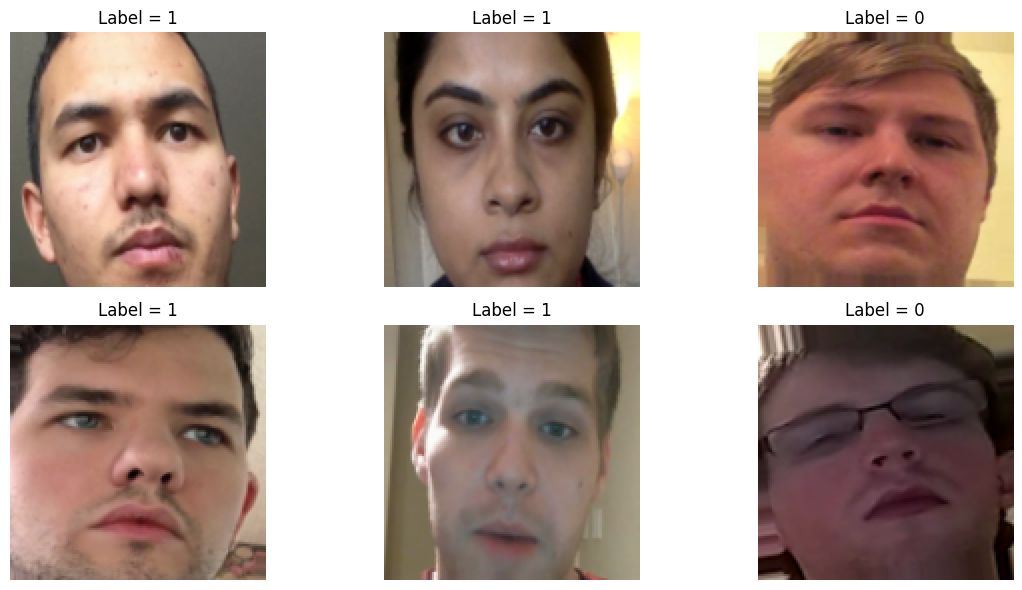

In [ ]:
### visualize some training images
images, labels = next(train_generator)

plt.figure(figsize=(12,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("Label = " + str(int(labels[i])))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
### building cnn model
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))
model.add(BatchNormalization())

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(BatchNormalization())

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(BatchNormalization())

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/home/anirbannayak/DL_PROJECT/dl-venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1776438373.227900  125015 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776438375.334068  124832 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 63, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,665 (12.61 MB)

 Trainable params: 3,305,217 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3
)

In [9]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/25


I0000 00:00:1776438436.215796  124832 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


760/760 ━━━━━━━━━━━━━━━━━━━━ 238s 310ms/step - accuracy: 0.9586 - loss: 0.1664 - val_accuracy: 0.6680 - val_loss: 3.8160 - learning_rate: 0.0010
Epoch 2/25
760/760 ━━━━━━━━━━━━━━━━━━━━ 237s 312ms/step - accuracy: 0.9867 - loss: 0.0520 - val_accuracy: 0.4076 - val_loss: 10.1112 - learning_rate: 0.0010
Epoch 3/25
760/760 ━━━━━━━━━━━━━━━━━━━━ 237s 312ms/step - accuracy: 0.9929 - loss: 0.0248 - val_accuracy: 0.4820 - val_loss: 10.7537 - learning_rate: 0.0010
Epoch 4/25
760/760 ━━━━━━━━━━━━━━━━━━━━ 237s 312ms/step - accuracy: 0.9921 - loss: 0.0345 - val_accuracy: 0.5042 - val_loss: 19.7702 - learning_rate: 0.0010
Epoch 5/25
760/760 ━━━━━━━━━━━━━━━━━━━━ 238s 314ms/step - accuracy: 0.9975 - loss: 0.0096 - val_accuracy: 0.4135 - val_loss: 16.1789 - learning_rate: 5.0000e-04
Epoch 6/25
760/760 ━━━━━━━━━━━━━━━━━━━━ 238s 313ms/step - accuracy: 0.9986 - loss: 0.0052 - val_accuracy: 0.3747 - val_loss: 19.0019 - learning_rate: 5.0000e-04


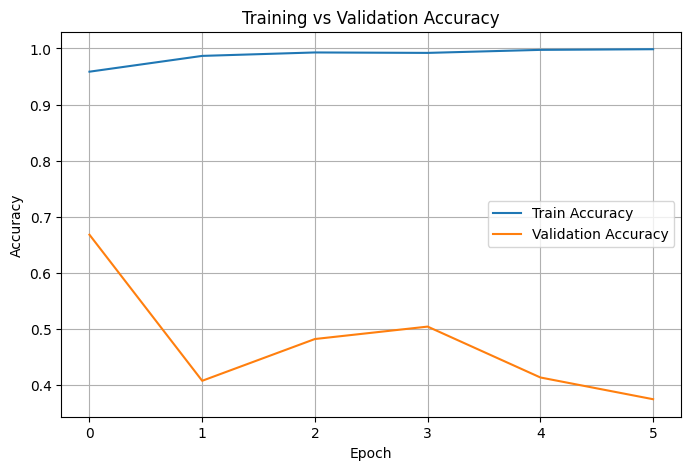

In [ ]:
### plotting accuracy curve
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

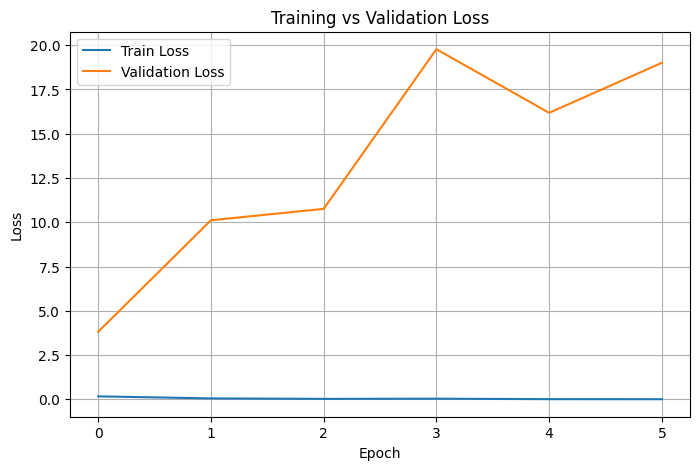

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
## test accuracy
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy =", round(test_acc*100,2), "%")

304/304 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.5811 - loss: 4.5896
Test Accuracy = 58.11 %


In [13]:
pred_prob = model.predict(test_generator)

pred = (pred_prob > 0.5).astype(int).reshape(-1)

true = test_generator.classes

304/304 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step


In [14]:
print(classification_report(true, pred, target_names=["drowsy","non_drowsy"]))

              precision    recall  f1-score   support

      drowsy       0.57      0.62      0.60      4813
  non_drowsy       0.59      0.54      0.57      4906

    accuracy                           0.58      9719
   macro avg       0.58      0.58      0.58      9719
weighted avg       0.58      0.58      0.58      9719



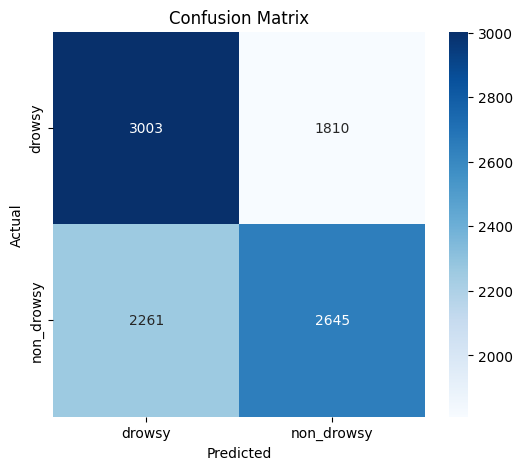

In [15]:
cm = confusion_matrix(true, pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["drowsy","non_drowsy"],
    yticklabels=["drowsy","non_drowsy"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

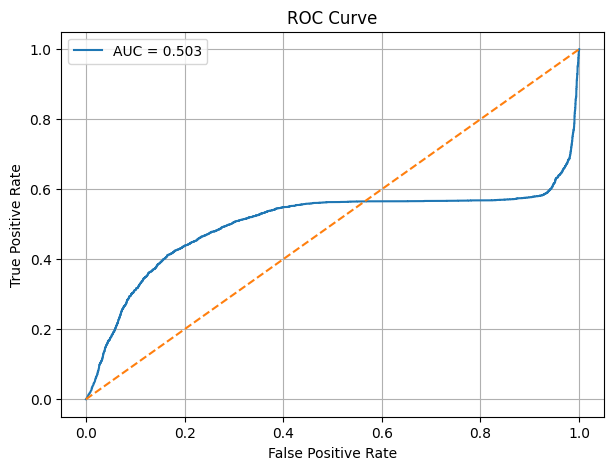

ROC-AUC Score = 0.503


In [16]:
fpr, tpr, thresholds = roc_curve(true, pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

print("ROC-AUC Score =", round(roc_auc,3))

## visualization

In [ ]:
### predict full test data
test_generator.reset()

pred_prob = model.predict(test_generator, verbose=1)
pred = (pred_prob > 0.5).astype(int).reshape(-1)

true = test_generator.classes
files = test_generator.filenames

print("Total Test Images:", len(files))
print("Predictions completed.")

304/304 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step
Total Test Images: 9719
Predictions completed.


In [ ]:
## helper function
import os
import re

def get_prefix(filepath):
    name = os.path.basename(filepath)
    match = re.match(r"[A-Za-z]+", name)
    return match.group()

label_map = {
    0: "drowsy",
    1: "non_drowsy"
}

In [ ]:
###
drowsy_idx = []
non_idx = []

for i in range(len(true)):
    
    if true[i] == 0:
        drowsy_idx.append(i)
    else:
        non_idx.append(i)

print("True Drowsy Images:", len(drowsy_idx))
print("True Non-Drowsy Images:", len(non_idx))

True Drowsy Images: 4813
True Non-Drowsy Images: 4906


In [ ]:
## create 4 catagories
correct_drowsy = []
wrong_drowsy = []

correct_non = []
wrong_non = []

for i in range(len(true)):

    t = true[i]
    p = pred[i]

    # True = drowsy
    if t == 0:
        if p == 0:
            correct_drowsy.append(i)
        else:
            wrong_drowsy.append(i)

    # True = non_drowsy
    else:
        if p == 1:
            correct_non.append(i)
        else:
            wrong_non.append(i)

print("Correct Drowsy     :", len(correct_drowsy))
print("Wrong Drowsy       :", len(wrong_drowsy))
print("Correct NonDrowsy  :", len(correct_non))
print("Wrong NonDrowsy    :", len(wrong_non))

Correct Drowsy     : 3003
Wrong Drowsy       : 1810
Correct NonDrowsy  : 2645
Wrong NonDrowsy    : 2261


In [ ]:
###Helper Function to Pick Different Persons
def pick_unique_samples(index_list, n_samples=5):
    
    chosen = []
    used_persons = set()

    for idx in index_list:

        person = get_prefix(files[idx]).lower()

        if person not in used_persons:
            chosen.append(idx)
            used_persons.add(person)

        if len(chosen) == n_samples:
            break

    return chosen

In [46]:
sample_cd = pick_unique_samples(correct_drowsy, 5)
sample_wd = pick_unique_samples(wrong_drowsy, 5)

sample_cn = pick_unique_samples(correct_non, 5)
sample_wn = pick_unique_samples(wrong_non, 5)

print("Correct Drowsy Samples    :", len(sample_cd))
print("Wrong Drowsy Samples      :", len(sample_wd))
print("Correct Non Samples       :", len(sample_cn))
print("Wrong Non Samples         :", len(sample_wn))

Correct Drowsy Samples    : 5
Wrong Drowsy Samples      : 5
Correct Non Samples       : 3
Wrong Non Samples         : 5


In [47]:
selected = sample_cd + sample_wd + sample_cn + sample_wn

print("Total Images Selected:", len(selected))

Total Images Selected: 18


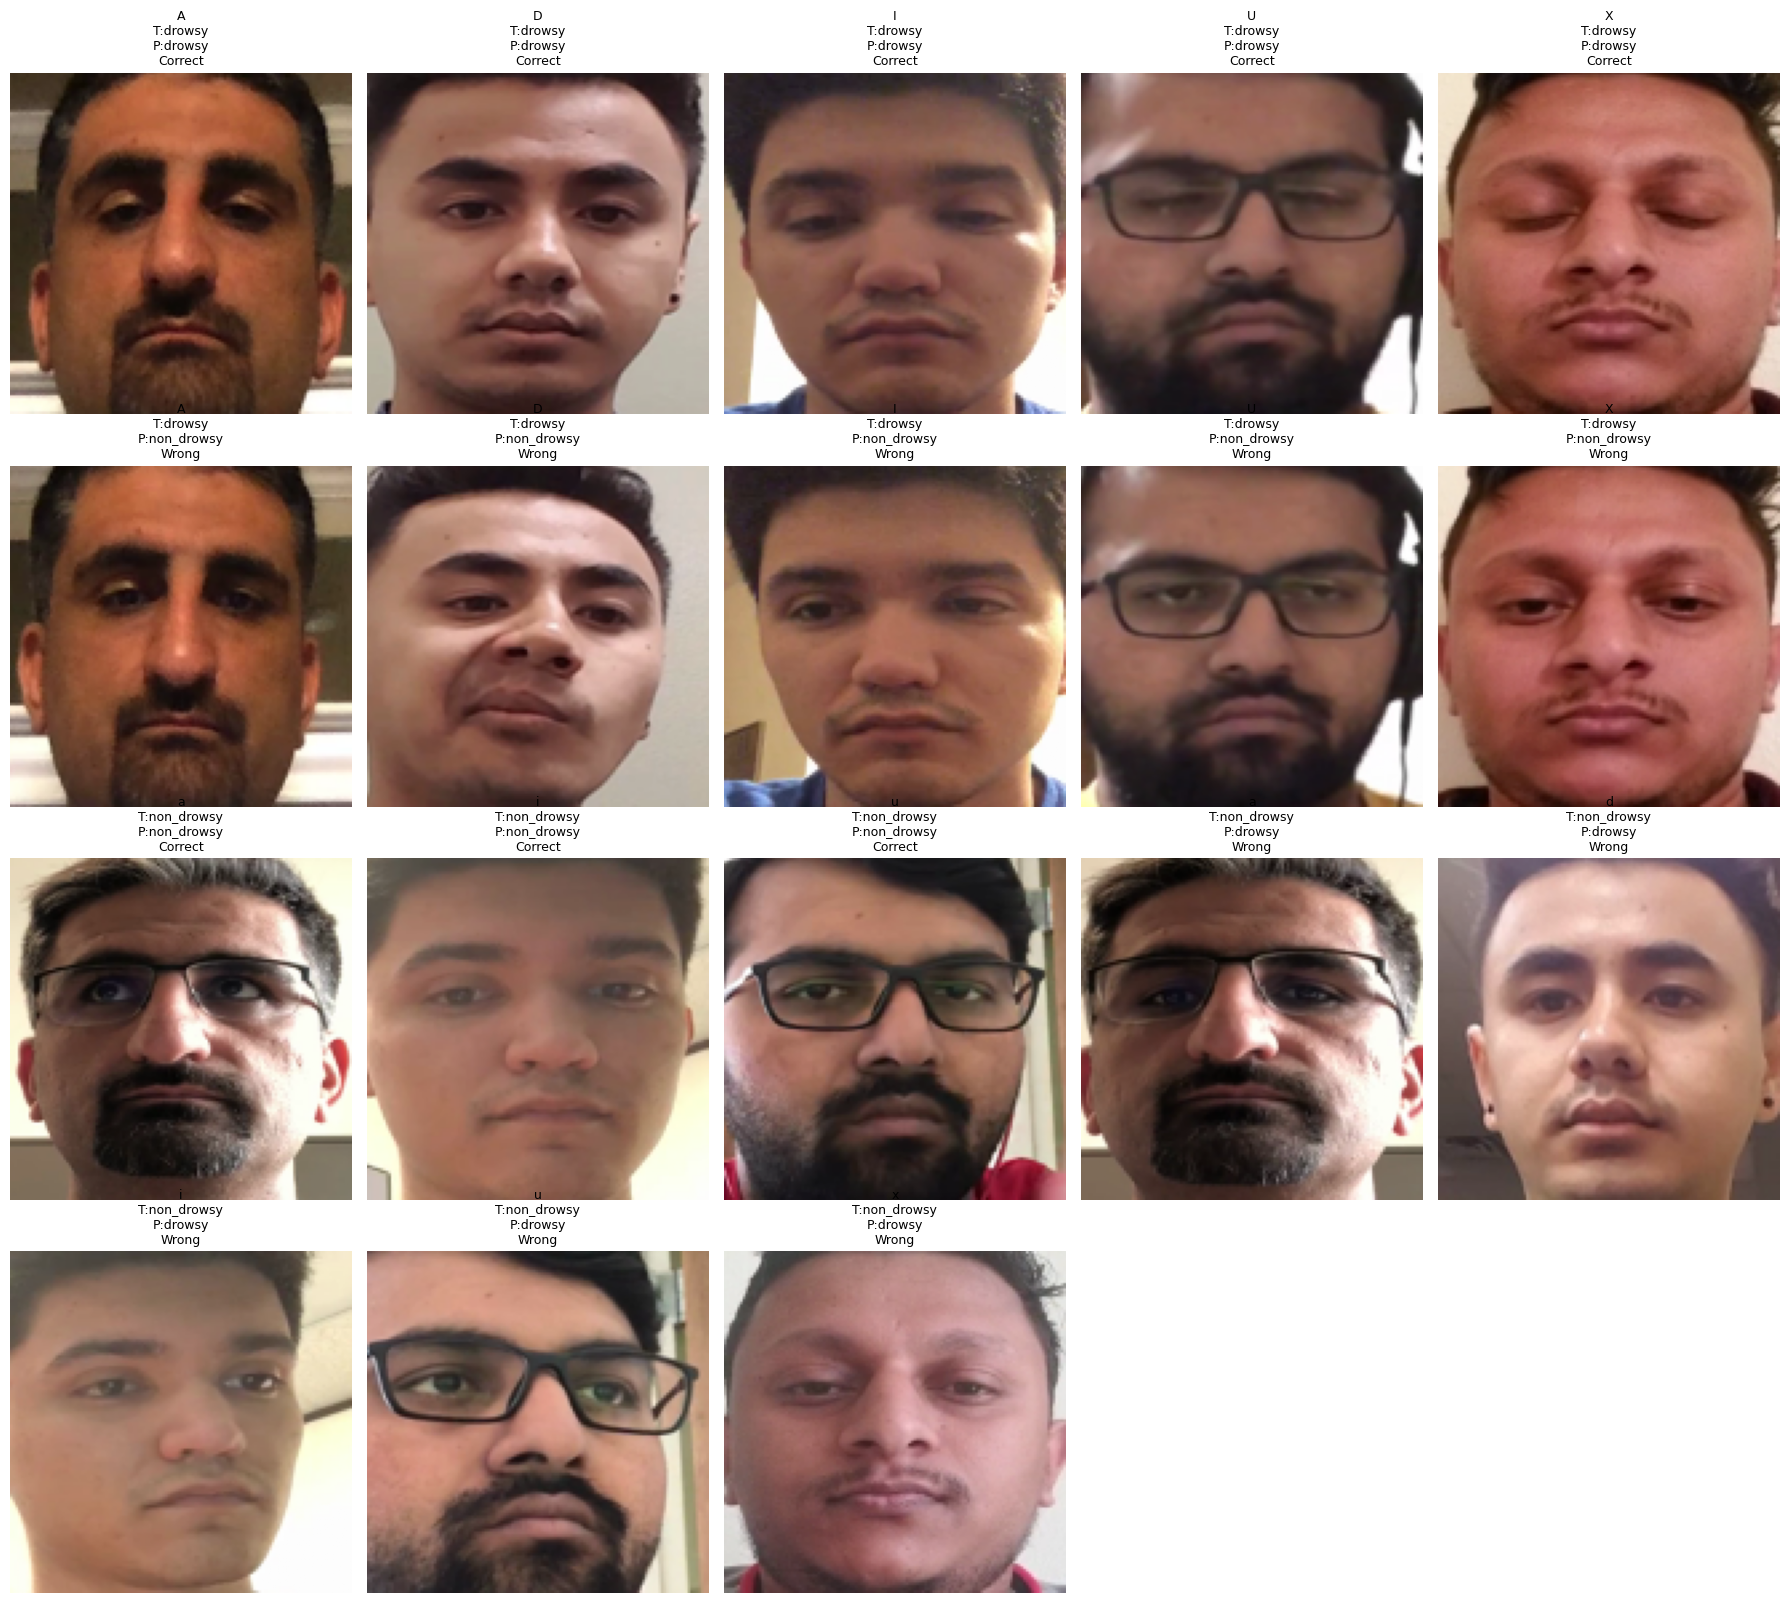

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,16))

for i, idx in enumerate(selected):

    img_path = os.path.join(test_path, files[idx])
    img = plt.imread(img_path)

    person = get_prefix(files[idx])

    t = true[idx]
    p = pred[idx]

    true_label = label_map[t]
    pred_label = label_map[p]

    result = "Correct" if t == p else "Wrong"

    plt.subplot(4,5,i+1)
    plt.imshow(img)

    plt.title(
        f"{person}\nT:{true_label}\nP:{pred_label}\n{result}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()